In [1]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [2]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [3]:
check_data(image_path)

# of directories: 2 and 1 images in 'imagewoof200'.
# of directories: 10 and 1 images in 'imagewoof200/test'.
# of directories: 0 and 48 images in 'imagewoof200/test/australian_terrier'.
# of directories: 0 and 48 images in 'imagewoof200/test/beagle'.
# of directories: 0 and 48 images in 'imagewoof200/test/shih_tzu'.
# of directories: 0 and 48 images in 'imagewoof200/test/rhodesian_ridgeback'.
# of directories: 0 and 48 images in 'imagewoof200/test/samoyed'.
# of directories: 0 and 48 images in 'imagewoof200/test/golden_retriever'.
# of directories: 0 and 48 images in 'imagewoof200/test/border_terrier'.
# of directories: 0 and 48 images in 'imagewoof200/test/dingo'.
# of directories: 0 and 48 images in 'imagewoof200/test/old_english_sheepdog'.
# of directories: 0 and 48 images in 'imagewoof200/test/english_foxhound'.
# of directories: 10 and 1 images in 'imagewoof200/train'.
# of directories: 0 and 200 images in 'imagewoof200/train/australian_terrier'.
# of directories: 0 and 200 image

In [4]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [5]:
from torchvision import transforms,datasets

In [6]:
manual_transforms = transforms.Compose([
    transforms.Resize(size = (224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [7]:
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32
def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transforms: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):
  train_data = datasets.ImageFolder(train_dir, transform=transforms)
  test_data = datasets.ImageFolder(test_dir, transform=transforms)

  class_names = train_data.classes
    
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

  return train_dataloader, test_dataloader, class_names

In [8]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                   test_dir=test_dir,
                                                                   transforms=manual_transforms,
                                                                   batch_size=BATCH_SIZE,
                                                                   num_workers=NUM_WORKERS)

In [9]:
train_dataloader

In [10]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [55]:
import torchvision
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [57]:
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [59]:
auto_transforms = weights.transforms()

In [61]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [63]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                   test_dir=test_dir,
                                                                   transforms=auto_transforms,
                                                                   batch_size=BATCH_SIZE,
                                                                   num_workers=NUM_WORKERS)

In [69]:
import torch
torch.mps.is_available()

True

In [123]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

In [73]:
device

'mps'

In [75]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [77]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [79]:
!pip install torchinfo


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [81]:
from torchinfo import summary

In [107]:
summary(model = model,
        input_size=(32,3,224,224),
        col_names = ['input_size','output_size','num_params','trainable'])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        True
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        True
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        True
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        864                       True
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        64                        True
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential: 2-2  

In [109]:
for param in model.features.parameters():
    param.requires_grad = False

In [111]:
summary(model = model,
        input_size=(32,3,224,224),
        col_names = ['input_size','output_size','num_params','trainable'])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [113]:
len(class_names)

10

In [115]:
output_shape = len(class_names)

In [117]:
from torch import nn
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=output_shape, bias=True)
).to(device)

In [119]:
summary(model = model,
        input_size=(32,3,224,224),
        col_names = ['input_size','output_size','num_params','trainable'])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 10]                  --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [121]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [137]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
              device : torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
             device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
         device: torch.device = None):

    if device is None:
        device = torch.device("mps" if torch.mps.is_available() else "cpu")
    
    model = model.to(device)

    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                       device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        # results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        # results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        # results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        # results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)


    # 6. Return the filled results at the end of the epochs
    return results

In [139]:
results = train(model = model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device)

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch: 1 | train_loss: 1.3765 | train_acc: 0.6994 | test_loss: 0.7401 | test_acc: 0.8604
Epoch: 2 | train_loss: 0.7018 | train_acc: 0.8452 | test_loss: 0.5293 | test_acc: 0.8688
Epoch: 3 | train_loss: 0.5351 | train_acc: 0.8760 | test_loss: 0.4531 | test_acc: 0.8917
Epoch: 4 | train_loss: 0.4530 | train_acc: 0.8934 | test_loss: 0.4228 | test_acc: 0.8875
Epoch: 5 | train_loss: 0.4024 | train_acc: 0.9013 | test_loss: 0.4140 | test_acc: 0.8875


In [159]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(img).unsqueeze(dim=0)
        target_image_pred = model(transformed_image.to(device))
        target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
        target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.2f}")
    plt.axis(False)

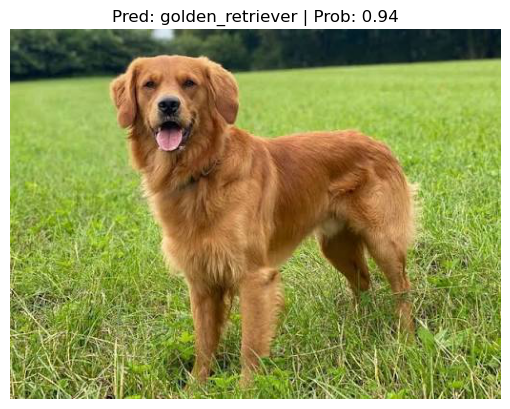

In [161]:
custom_image_path = data_path / "golden.jpeg"
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

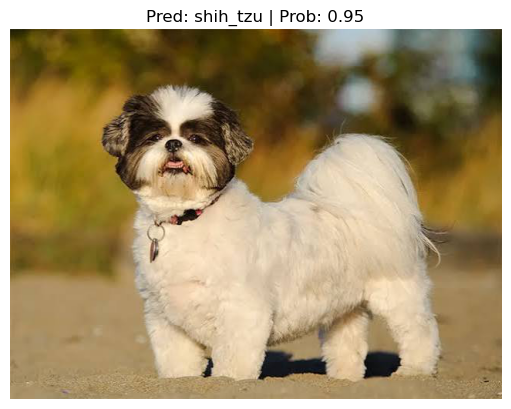

In [163]:
custom_image_path = data_path / "shihtzu.jpeg"
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)